# Notebook 1 — `text_conversion.ipynb`

Sovereign Dialect-Bridge · Step 1 — Data Preparation & EDA

Transformasi raw IndoSum (JSONL, nested token format) ke Parquet bersih dan EDA.
Output dipakai oleh `training_sum.ipynb` (Notebook 3) dan `inference.ipynb` (Notebook 4).

Input:** `dataset/indosum/{train,dev,test}.01.jsonl` (fold 1 dari 5-fold CV).

**Output:
- `data/train.parquet`, `data/val.parquet`, `data/test.parquet` (test = 700 stratified samples)
- `data/train_sample.csv` (100 baris untuk inspeksi manual, tanpa kolom list)

Notebook ini tidak butuh GPU — bisa dijalankan di CPU lokal.

## 1. Setup environment

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"]   = "0"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import json, re, random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd

try:
    import torch
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
except ImportError:
    DEVICE = "cpu"

print(f"Device : {DEVICE}")
print(f"Pandas : {pd.__version__} | NumPy: {np.__version__}")


Device : cpu
Pandas : 2.3.3 | NumPy: 2.2.6


## 2. Install dependencies

Cukup dijalankan sekali per session.

```bash
pip install pandas pyarrow fastparquet matplotlib seaborn
```

## 3. Paths & configuration

In [2]:
# Auto-detect project root: notebook bisa dijalankan dari notebook/ atau dari root
CWD = Path.cwd()
if (CWD / "dataset" / "indosum").exists():
    ROOT = CWD
elif (CWD.parent / "dataset" / "indosum").exists():
    ROOT = CWD.parent
else:
    raise FileNotFoundError(
        "Tidak menemukan dataset/indosum/ — jalankan dari root project atau notebook/"
    )

DATASET_DIR = ROOT / "dataset" / "indosum"
OUTPUT_DIR  = ROOT / "data"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Konfigurasi global (sinkron dengan CLAUDE.md)
TRAIN_SUBSET = 10000
N_VAL        = 750
N_TEST       = 700
RANDOM_SEED  = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print(f"ROOT       : {ROOT}")
print(f"DATASET_DIR: {DATASET_DIR}")
print(f"OUTPUT_DIR : {OUTPUT_DIR}")


ROOT       : /Users/fadh/Documents/BINUS/Semester 4/Project_Summarize_NLP
DATASET_DIR: /Users/fadh/Documents/BINUS/Semester 4/Project_Summarize_NLP/dataset/indosum
OUTPUT_DIR : /Users/fadh/Documents/BINUS/Semester 4/Project_Summarize_NLP/data


## 4. Helper functions

Raw IndoSum punya struktur bersarang: `paragraphs[p][s][w]` (paragraf x kalimat x kata).
Helper di bawah meratakan dan menggabung token sambil memperbaiki spasi sebelum tanda baca.

In [4]:
def flatten_nested_tokens(nested) -> str:
    # Flatten arbitrary nested list of tokens into a clean string.
    if isinstance(nested, str):
        return nested.strip()
    parts = []
    for item in nested:
        if isinstance(item, list):
            parts.append(flatten_nested_tokens(item))
        else:
            parts.append(str(item))
    text = " ".join(parts)
    text = re.sub(r"\s([.,!?;:\)\]])", r"\1", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def sentence_to_str(sent_tokens) -> str:
    # One sentence (list of word tokens) to a clean string.
    return flatten_nested_tokens(sent_tokens)


def flatten_paragraphs_to_sentences(paragraphs):
    # 3-level paragraphs to flat list of sentence strings.
    sents = []
    for para in paragraphs:
        for sent in para:
            s = sentence_to_str(sent)
            if s:
                sents.append(s)
    return sents


def flatten_gold_labels(gold_labels):
    # 2-level gold_labels (paragraph x sentence) to flat list of int.
    out = []
    for para in gold_labels:
        for lab in para:
            out.append(int(bool(lab)))
    return out


def is_article_complete(text: str) -> bool:
    # Heuristik: artikel dianggap utuh jika diakhiri tanda baca akhir kalimat.
    if not text:
        return False
    return text.rstrip()[-1:] in {".", "!", "?", '"', "'", ")"}


# Sanity check
_sample = [[["Halo", "dunia", "."], ["Selamat", "pagi", "!"]], [["Apa", "kabar", "?"]]]
print(flatten_paragraphs_to_sentences(_sample))
print(flatten_gold_labels([[True, False], [True]]))


['Halo dunia.', 'Selamat pagi!', 'Apa kabar?']
[1, 0, 1]


## 5. Load JSONL records

In [5]:
def load_jsonl(path: Path) -> list:
    records = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return records


raw_train = load_jsonl(DATASET_DIR / "train.01.jsonl")
raw_val   = load_jsonl(DATASET_DIR / "dev.01.jsonl")
raw_test  = load_jsonl(DATASET_DIR / "test.01.jsonl")

print(f"Raw train: {len(raw_train):,}")
print(f"Raw val  : {len(raw_val):,}")
print(f"Raw test : {len(raw_test):,}")
print("Keys:", list(raw_train[0].keys()))


Raw train: 14,262
Raw val  : 750
Raw test : 3,762
Keys: ['category', 'gold_labels', 'id', 'paragraphs', 'source', 'source_url', 'summary']


In [6]:
# Inspect raw structure of one record before any processing
sample_raw = raw_train[0]
print("Keys     :", list(sample_raw.keys()))
print("category :", sample_raw.get("category"))
print("source   :", sample_raw.get("source"))
print("id       :", sample_raw.get("id"))

paras = sample_raw["paragraphs"]
print(f"\nparagraphs: {len(paras)} paragraphs")
for i, para in enumerate(paras[:3]):
    print(f"  para[{i}]: {len(para)} sentences, first tokens = {para[0][:5]}")

gold = sample_raw["gold_labels"]
print(f"\ngold_labels: {len(gold)} paragraphs, labels per para = {[len(p) for p in gold]}")

summ = sample_raw["summary"]
print(f"\nsummary: {len(summ)} sentences, first = {summ[0][:8]}")


Keys     : ['category', 'gold_labels', 'id', 'paragraphs', 'source', 'source_url', 'summary']
category : tajuk utama
source   : cnn indonesia
id       : 1501893029-lula-kamal-dokter-ryan-thamrin-sakit-sejak-setahun

paragraphs: 9 paragraphs
  para[0]: 2 sentences, first tokens = ['Jakarta', ',', 'CNN', 'Indonesia', '-']
  para[1]: 2 sentences, first tokens = ['Lula', 'menuturkan', ',', 'sakit', 'itu']
  para[2]: 3 sentences, first tokens = ['"', 'Setahu', 'saya', 'dia', 'orangnya']

gold_labels: 9 paragraphs, labels per para = [2, 2, 3, 2, 2, 2, 2, 1, 2]

summary: 3 sentences, first = ['Dokter', 'Lula', 'Kamal', 'yang', 'merupakan', 'selebriti', 'sekaligus', 'rekan']


## 6. Build typed records with full schema

Setiap record dibangun dengan kolom: `id, category, source, text, summary, sentences,
sentence_labels, oracle_summary, word_count, summary_word_count, compression_ratio,
n_sentences, is_complete`.

> **Catatan:** `summary` di-flatten apa adanya — tidak di-lowercase, tidak di-stem.
> Ini penting agar ROUGE scoring tetap akurat.

In [7]:
def build_record(raw: dict) -> dict:
    paragraphs = raw.get("paragraphs", [])
    summary    = raw.get("summary", [])
    gold       = raw.get("gold_labels", [])

    sentences       = flatten_paragraphs_to_sentences(paragraphs)
    sentence_labels = flatten_gold_labels(gold)

    text        = " ".join(sentences)
    summary_str = flatten_nested_tokens(summary)
    oracle      = " ".join(s for s, lab in zip(sentences, sentence_labels) if lab == 1)

    w_count = len(text.split())
    s_count = len(summary_str.split())
    cr      = (s_count / w_count) if w_count > 0 else 0.0

    return {
        "id"                 : raw.get("id", ""),
        "category"           : raw.get("category", ""),
        "source"             : raw.get("source", ""),
        "text"               : text,
        "summary"            : summary_str,
        "sentences"          : sentences,
        "sentence_labels"    : sentence_labels,
        "oracle_summary"     : oracle,
        "word_count"         : w_count,
        "summary_word_count" : s_count,
        "compression_ratio"  : round(cr, 4),
        "n_sentences"        : len(sentences),
        "is_complete"        : is_article_complete(text),
        "_len_match"         : len(sentences) == len(sentence_labels),
    }


df_train_raw = pd.DataFrame([build_record(r) for r in raw_train])
df_val_raw   = pd.DataFrame([build_record(r) for r in raw_val])
df_test_raw  = pd.DataFrame([build_record(r) for r in raw_test])

print(f"Built train: {len(df_train_raw):,}")
print(f"Built val  : {len(df_val_raw):,}")
print(f"Built test : {len(df_test_raw):,}")
print("\nCategory distribution (train):")
print(df_train_raw["category"].value_counts())


Built train: 14,262
Built val  : 750
Built test : 3,762

Category distribution (train):
category
tajuk utama    5454
olahraga       3624
showbiz        1982
teknologi      1734
hiburan        1372
inspirasi        96
Name: count, dtype: int64


In [8]:
# Preview processed DataFrame — shape, column types, and first 10 rows
print(f"Shape  : {df_train_raw.shape}")
print(f"Columns: {list(df_train_raw.columns)}\n")

display_cols = [
    "id", "category", "word_count", "summary_word_count",
    "compression_ratio", "n_sentences", "is_complete", "_len_match",
]
df_train_raw[display_cols].head(10)


Shape  : (14262, 14)
Columns: ['id', 'category', 'source', 'text', 'summary', 'sentences', 'sentence_labels', 'oracle_summary', 'word_count', 'summary_word_count', 'compression_ratio', 'n_sentences', 'is_complete', '_len_match']



,id,category,word_count,summary_word_count,compression_ratio,n_sentences,is_complete,_len_match
0,1501893029-lula-kamal-dokter-ryan-thamrin-saki...,tajuk utama,287,53,0.1847,18,True,True
1,1509072914-dua-smartphone-zenfone-baru-tawarka...,teknologi,758,57,0.0752,40,True,True
2,1510613677-songsong-visit-2020-bengkulu-perkua...,hiburan,543,58,0.1068,25,True,True
3,1502706803-icw-ada-kejanggalan-atas-tewasnya-s...,tajuk utama,191,66,0.3455,11,False,True
4,1503039338-pembagian-sepeda-usai-upacara-penur...,tajuk utama,252,61,0.2421,13,False,True
5,1512519514-hasil-indonesia-vs-mongolia,olahraga,415,61,0.1470,33,True,True
6,1508286852-hp-luncurkan-kamera-instan-sprocket...,teknologi,266,61,0.2293,16,True,True
7,1497686400-mourinho-minta-100-juta-pounds-untu...,olahraga,152,61,0.4013,7,True,True
8,1491930003-persib-pastikan-jamu-arema-di-stadi...,olahraga,236,70,0.2966,13,True,True
9,1501262100-seberapa-butuh-juventus-akan-keita-...,olahraga,679,61,0.0898,45,True,True


## 7. Quality control filter

Buang record yang:
- `word_count < 50` (artikel terlalu pendek)
- `summary_word_count < 10` (summary terlalu pendek)
- `compression_ratio > 0.75` atau `< 0.03`
- `is_complete == False` (artikel terpotong)
- `_len_match == False` (mismatch sentences/labels)
- Tidak ada oracle sentence (`sum(sentence_labels) == 0`)

In [9]:
def qc_filter(df: pd.DataFrame, name: str) -> pd.DataFrame:
    n0 = len(df)
    print(f"\n-- QC filter on {name} ({n0:,}) --")

    mask_mismatch   = ~df["_len_match"]
    mask_short_art  = df["word_count"] < 50
    mask_short_sum  = df["summary_word_count"] < 10
    mask_cr_high    = df["compression_ratio"] > 0.75
    mask_cr_low     = df["compression_ratio"] < 0.03
    mask_incomplete = ~df["is_complete"]
    mask_no_oracle  = df["sentence_labels"].apply(lambda x: sum(x) == 0)

    for label, mask in [
        ("  len mismatch    ", mask_mismatch),
        ("  word_count < 50 ", mask_short_art),
        ("  sum_words < 10  ", mask_short_sum),
        ("  CR > 0.75       ", mask_cr_high),
        ("  CR < 0.03       ", mask_cr_low),
        ("  not complete    ", mask_incomplete),
        ("  no oracle sents ", mask_no_oracle),
    ]:
        print(f"{label}: {int(mask.sum()):,}")

    keep = ~(
        mask_mismatch | mask_short_art | mask_short_sum |
        mask_cr_high  | mask_cr_low    | mask_incomplete | mask_no_oracle
    )
    df = df[keep].drop(columns=["_len_match"]).reset_index(drop=True)
    print(f"  kept {len(df):,} / {n0:,} ({len(df)/n0:.1%})")
    return df


df_train = qc_filter(df_train_raw, "train")
df_val   = qc_filter(df_val_raw,   "val")
df_test  = qc_filter(df_test_raw,  "test")



-- QC filter on train (14,262) --
  len mismatch    : 0
  word_count < 50 : 2
  sum_words < 10  : 0
  CR > 0.75       : 29
  CR < 0.03       : 0
  not complete    : 1,268
  no oracle sents : 2
  kept 12,966 / 14,262 (90.9%)

-- QC filter on val (750) --
  len mismatch    : 0
  word_count < 50 : 1
  sum_words < 10  : 0
  CR > 0.75       : 5
  CR < 0.03       : 0
  not complete    : 67
  no oracle sents : 0
  kept 679 / 750 (90.5%)

-- QC filter on test (3,762) --
  len mismatch    : 0
  word_count < 50 : 0
  sum_words < 10  : 0
  CR > 0.75       : 8
  CR < 0.03       : 0
  not complete    : 374
  no oracle sents : 0
  kept 3,381 / 3,762 (89.9%)


## 8. Subsetting & stratified split

- Train: ambil **10.000 sampel** (cukup untuk hasil baik, hemat training time).
- Val: gunakan semua hasil filter dari `dev.01.jsonl`.
- Test: **700 sampel stratified per kategori** (representatif lintas 6 kategori berita).

In [10]:
def stratified_subset(df: pd.DataFrame, n: int, by: str = "category",
                      seed: int = RANDOM_SEED) -> pd.DataFrame:
    if len(df) <= n:
        return df.sample(frac=1, random_state=seed).reset_index(drop=True)
    fracs   = df[by].value_counts(normalize=True)
    per_cat = (fracs * n).round().astype(int).to_dict()
    parts   = []
    for cat, k in per_cat.items():
        sub = df[df[by] == cat]
        k   = min(k, len(sub))
        if k > 0:
            parts.append(sub.sample(k, random_state=seed))
    out = pd.concat(parts).sample(frac=1, random_state=seed).reset_index(drop=True)
    if len(out) > n:
        out = out.head(n)
    return out


df_train_final = stratified_subset(df_train, TRAIN_SUBSET)
df_val_final   = df_val.copy() if len(df_val) <= N_VAL else stratified_subset(df_val, N_VAL)
df_test_final  = stratified_subset(df_test, N_TEST)

print(f"Final train : {len(df_train_final):,}")
print(f"Final val   : {len(df_val_final):,}")
print(f"Final test  : {len(df_test_final):,}")
print("\nTest distribution per category:")
print(df_test_final["category"].value_counts())


Final train : 10,000
Final val   : 679
Final test  : 700

Test distribution per category:
category
tajuk utama    262
olahraga       179
showbiz         98
teknologi       94
hiburan         62
inspirasi        5
Name: count, dtype: int64


In [11]:
# Show sentence-label alignment on one record to verify oracle labels are sensible
example = df_train_final.iloc[0]
print(f"Article  : {example['id']}")
print(f"Category : {example['category']}")
print(f"Sentences: {example['n_sentences']}  |  Oracle sentences: {sum(example['sentence_labels'])}")
print()
for i, (sent, lab) in enumerate(zip(example["sentences"][:6], example["sentence_labels"][:6])):
    tag = "[ORACLE]" if lab == 1 else "        "
    print(f"  {tag} [{i}] {sent[:90]}")


Article  : 1501781400-montella-milan-tidak-terburu-buru-rekrut-penyerang
Category : olahraga
Sentences: 19  |  Oracle sentences: 2

  [ORACLE] [0] Pelatih AC Milan Vincenzo Montella mengatakan klubnya tidak sedang dikejar waktu untuk seg
           [1] Sejauh ini Milan telah merekrut sepuluh pemain termasuk penyerang asal Portugal Andre Silv
           [2] Mereka juga telah berhasil memperpanjang kontrak Gianluigi Donnarumma yang sebelumnya semp
  [ORACLE] [3] Akan tetapi Montella menyatakan Milan belum selesai dalam hal merekrut pemain baru, bebera
           [4] SIMAK JUGA: Mino Raiola Tawarkan Zlatan Ibrahimovic Ke AC Milan
           [5] " Kami berhenti sesaat setelah bekerja keras [ di bursa transfer].


## 9. Save Parquet & sample CSV

In [ ]:
def save_split(df: pd.DataFrame, path: Path):
    df.to_parquet(path, index=False)
    print(f"  saved {path.name:25s}  rows={len(df):,}  cols={len(df.columns)}")


save_split(df_train_final, OUTPUT_DIR / "train.parquet")
save_split(df_val_final,   OUTPUT_DIR / "val.parquet")
save_split(df_test_final,  OUTPUT_DIR / "test.parquet")

# Sample CSV: drop list columns so it opens cleanly in Excel
csv_cols = [
    "id", "category", "source", "text", "summary",
    "word_count", "summary_word_count", "compression_ratio", "n_sentences",
]
df_train_final[csv_cols].head(100).to_csv(OUTPUT_DIR / "train_sample.csv", index=False)
printf("  saved train_sample.csv inrows=100")


  saved train.parquet              rows=10,000  cols=13
  saved val.parquet                rows=679  cols=13
  saved test.parquet               rows=700  cols=13
  saved train_sample.csv             rows=100


In [13]:
# Show a real article-summary pair to inspect data quality
sample = df_train_final.sample(1, random_state=0).iloc[0]
sep = "-" * 55

print(f"Category   : {sample['category']}")
print(f"Word count : {sample['word_count']}  |  Summary words: {sample['summary_word_count']}")
print(f"CR         : {sample['compression_ratio']:.3f}")
print(f"\n{sep} ARTICLE (first 400 chars) {sep}")
print(sample["text"][:400])
print(f"\n{sep} REFERENCE SUMMARY {sep}")
print(sample["summary"])
print(f"\n{sep} ORACLE SUMMARY (extractive gold) {sep}")
print(sample["oracle_summary"][:300])


Category   : teknologi
Word count : 348  |  Summary words: 56
CR         : 0.161

------------------------------------------------------- ARTICLE (first 400 chars) -------------------------------------------------------
Jakarta, CNN Indonesia - - Gagalnya Galaxy Note 7 di pasar ponsel pintar mengguncang Samsung sebagai perusahaan teknologi mengenai kelanjutan lini produknya di masa depan. Lini produk Note seakan menjadi pertaruhan besar bagi Samsung pasca insiden Galaxy Note 7 yang masih meledak setelah diganti dengan versi baru. Gara - gara insiden tersebut, Samsung terpaksa harus menghentikan produksi dan penju

------------------------------------------------------- REFERENCE SUMMARY -------------------------------------------------------
Gagalnya Galaxy Note 7 di pasar ponsel pintar mengguncang Samsung sebagai perusahaan teknologi mengenai kelanjutan lini produknya di masa depan. Senior Market Analyst Client Devices IDC Indonesia Reza Haryo yang menilai hal tersebut sebagai tampara

## 10. EDA — Distribusi panjang artikel & ringkasan

Target compression ratio natural IndoSum: **~0.225**.
Kalau distribusi train hasil filter masih di sekitar nilai itu, berarti QC tidak menyebabkan bias.

Train statistics:
       word_count  summary_word_count  compression_ratio
count    10000.00            10000.00           10000.00
mean       307.14               60.27               0.22
std        118.25                4.97               0.09
min         70.00               35.00               0.05
5%         153.00               52.00               0.11
50%        286.00               60.00               0.21
95%        523.05               68.00               0.39
max       1254.00              104.00               0.75


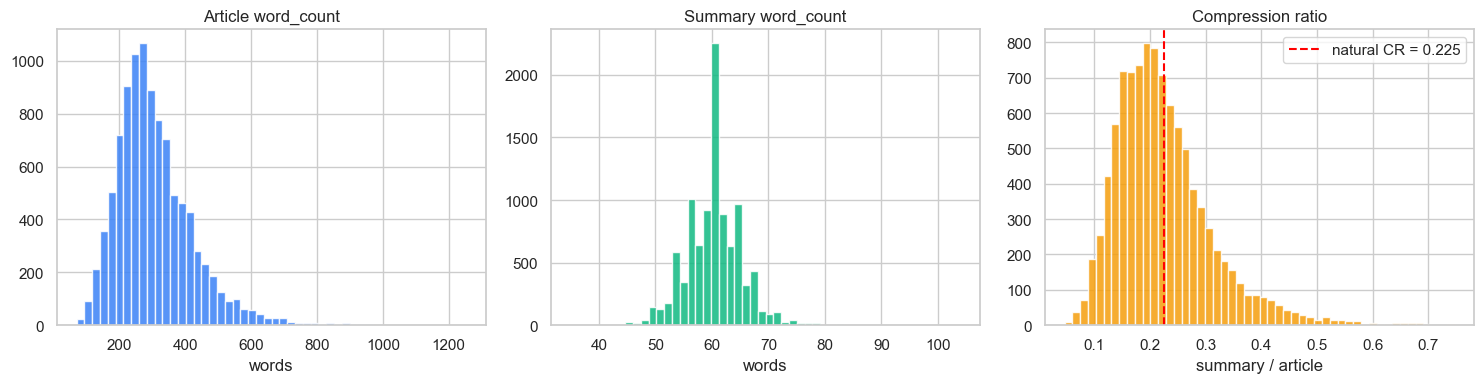

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

stats = df_train_final[["word_count", "summary_word_count", "compression_ratio"]].describe(
    percentiles=[0.05, 0.5, 0.95]
).round(2)
print("Train statistics:")
print(stats)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(df_train_final["word_count"], bins=50, color="#3b82f6", alpha=0.85)
axes[0].set_title("Article word_count")
axes[0].set_xlabel("words")
axes[1].hist(df_train_final["summary_word_count"], bins=50, color="#10b981", alpha=0.85)
axes[1].set_title("Summary word_count")
axes[1].set_xlabel("words")
axes[2].hist(df_train_final["compression_ratio"], bins=50, color="#f59e0b", alpha=0.85)
axes[2].axvline(0.225, color="red", linestyle="--", label="natural CR = 0.225")
axes[2].legend()
axes[2].set_title("Compression ratio")
axes[2].set_xlabel("summary / article")
plt.tight_layout()
plt.show()


## 11. EDA — Distribusi kategori

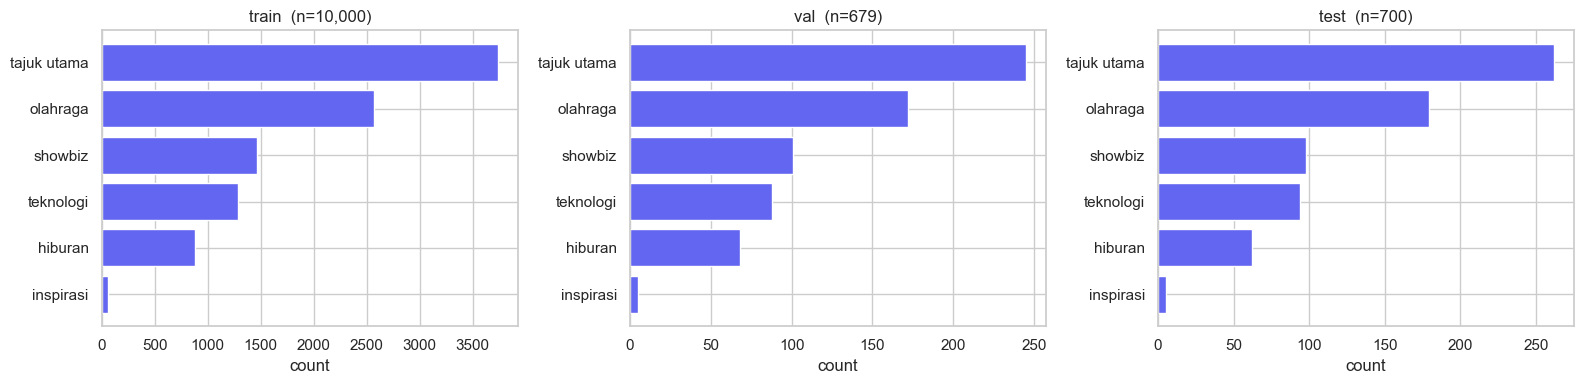


Imbalance ratio (max/min per split):
  train: 62.30x
  val: 49.00x
  test: 52.40x


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, df, title in zip(
    axes,
    [df_train_final, df_val_final, df_test_final],
    ["train", "val", "test"],
):
    vc = df["category"].value_counts()
    ax.barh(vc.index[::-1], vc.values[::-1], color="#6366f1")
    ax.set_title(f"{title}  (n={len(df):,})")
    ax.set_xlabel("count")
plt.tight_layout()
plt.show()

print("\nImbalance ratio (max/min per split):")
for df, name in [(df_train_final, "train"), (df_val_final, "val"), (df_test_final, "test")]:
    vc = df["category"].value_counts()
    print(f"  {name}: {vc.max() / max(vc.min(), 1):.2f}x")


## 12. EDA — Korelasi word_count vs summary_word_count

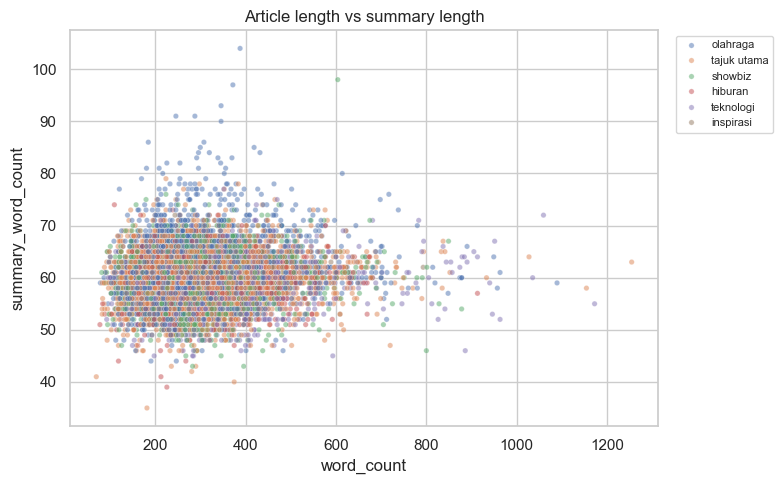

Pearson correlation: 0.061


In [17]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(
    data=df_train_final, x="word_count", y="summary_word_count",
    hue="category", alpha=0.5, s=15, ax=ax,
)
ax.set_title("Article length vs summary length")
ax.set_xlabel("word_count")
ax.set_ylabel("summary_word_count")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

corr = df_train_final[["word_count", "summary_word_count"]].corr().iloc[0, 1]
print(f"Pearson correlation: {corr:.3f}")


## 13. EDA — Top words artikel vs summary

In [18]:
ID_STOPWORDS = {
    "yang","di","ke","dari","dan","atau","ini","itu","dalam","untuk","pada","dengan",
    "sebagai","oleh","akan","juga","sudah","tidak","bukan","ada","tak","tapi","saat",
    "telah","saya","kami","kita","mereka","dia","ia","nya","ku","mu","se","dapat","bisa",
    "para","adalah","yaitu","yakni","hingga","sampai","jika","kalau","karena","sebab",
    "agar","supaya","bahwa","tentang","secara","seperti","menjadi","lebih","sangat",
    "masih","baru","banyak","semua","tahun","hari","orang",
}

def top_tokens(texts, k=15, min_len=3):
    tokens = []
    for t in texts:
        for w in re.findall(r"[A-Za-z\u00C0-\u00FF]+", t.lower()):
            if len(w) >= min_len and w not in ID_STOPWORDS:
                tokens.append(w)
    return Counter(tokens).most_common(k)


print("Top-15 dalam TEXT:")
for w, c in top_tokens(df_train_final["text"], 15):
    print(f"  {w:20s}  {c:,}")
print("\nTop-15 dalam SUMMARY:")
for w, c in top_tokens(df_train_final["summary"], 15):
    print(f"  {w:20s}  {c:,}")


Top-15 dalam TEXT:
  indonesia             14,492
  tersebut              12,594
  jakarta               10,473
  kata                  8,410
  satu                  7,841
  namun                 6,782
  setelah               6,160
  dua                   5,781
  lalu                  5,767
  hanya                 5,722
  pemain                5,288
  kepada                5,280
  hal                   4,782
  mengatakan            4,768
  tim                   4,661

Top-15 dalam SUMMARY:
  tersebut              2,995
  indonesia             2,631
  jakarta               1,610
  satu                  1,558
  setelah               1,511
  mengatakan            1,272
  dua                   1,253
  lalu                  1,137
  namun                 1,121
  tim                   1,006
  salah                 985
  hal                   983
  presiden              953
  pemain                925
  musim                 919


## Selesai

Output yang dihasilkan:
- `data/train.parquet` — 10.000 samples, input training untuk `training_sum.ipynb`
- `data/val.parquet`   — validation set (~679 rows)
- `data/test.parquet`  — 700 stratified samples untuk evaluasi di `inference.ipynb`
- `data/train_sample.csv` — 100 baris tanpa kolom list, untuk inspeksi manual

**Langkah selanjutnya:** jalankan `training_normalizer.ipynb` untuk training Stage 1 normalizer (mT5-small: dialek ke Bahasa Indonesia baku).

# Cek Parquet Data

In [27]:
df_train_check = pd.read_parquet(OUTPUT_DIR / "train.parquet")
df_train_check.head()

,id,category,source,text,summary,sentences,sentence_labels,oracle_summary,word_count,summary_word_count,compression_ratio,n_sentences,is_complete
0,1501781400-montella-milan-tidak-terburu-buru-r...,olahraga,goal indonesia,Pelatih AC Milan Vincenzo Montella mengatakan ...,Pelatih AC Milan Vincenzo Montella mengatakan ...,[Pelatih AC Milan Vincenzo Montella mengatakan...,"[1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",Pelatih AC Milan Vincenzo Montella mengatakan ...,334,62,0.1856,19,True
1,1500401700-mutiara-hitam-yang-tak-pernah-berhe...,olahraga,cnn indonesia,"Jakarta, CNN Indonesia - - Julukan Mutiara Hit...",Julukan Mutiara Hitam yang disematkan kepada P...,"[Jakarta, CNN Indonesia - - Julukan Mutiara Hi...","[1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","Jakarta, CNN Indonesia - - Julukan Mutiara Hit...",432,61,0.1412,29,True
2,1501693860-pengeroyok-bobotoh-ricko-andrean-di...,tajuk utama,cnn indonesia,"Jakarta, CNN Indonesia - - Satuan Reserse Krim...",Satuan Reserse Kriminal Polrestabes Bandung be...,"[Jakarta, CNN Indonesia - - Satuan Reserse Kri...","[1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","Jakarta, CNN Indonesia - - Satuan Reserse Krim...",220,59,0.2682,14,True
3,1516054500-persib-tidak-bisa-gunakan-si-jalak-...,olahraga,cnn indonesia,"Jakarta, CNN Indonesia - - Persib Bandung dipa...",Persib Bandung dipastikan tidak bisa menggunak...,"[Jakarta, CNN Indonesia - - Persib Bandung dip...","[1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","Jakarta, CNN Indonesia - - Persib Bandung dipa...",301,62,0.2060,18,True
4,1479337228-lorenzo-dan-ducati-saling-mengalah,olahraga,cnn indonesia,"Jakarta, CNN Indonesia - - Manajer Ducati, Gig...",Manajer Ducati Gigi Dall'Igna menyebutkan bahw...,"[Jakarta, CNN Indonesia - - Manajer Ducati, Gi...","[0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0]",Jorge Lorenzo adalah pebalap cerdas dan saya y...,239,57,0.2385,16,True


In [24]:
df_val_check = pd.read_parquet(OUTPUT_DIR / "val.parquet")
df_val_check.head()

,id,category,source,text,summary,sentences,sentence_labels,oracle_summary,word_count,summary_word_count,compression_ratio,n_sentences,is_complete
0,1489536002-mentan-lepas-ekspor-perdana-daging-...,tajuk utama,suara,Menteri Pertanian Andi Amran Sulaiman mengatak...,Saat ini pemerintah terus meningkatkan pendapa...,[Menteri Pertanian Andi Amran Sulaiman mengata...,"[1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, ...",Menteri Pertanian Andi Amran Sulaiman mengatak...,498,67,0.1345,23,True
1,1514112565-hasil-real-madrid-vs-barcelona,olahraga,poskotanews,SPANYOL – Barcelona berhasil memboyong kemenan...,Barcelona berhasil memboyong kemenangan besar ...,[SPANYOL – Barcelona berhasil memboyong kemena...,"[1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",SPANYOL – Barcelona berhasil memboyong kemenan...,612,67,0.1095,42,True
2,1508483400-jayawijaya-datangkan-arkeolog-untuk...,hiburan,antaranews,Wamena ( ANTARA News) - Pemerintah Kabupaten J...,"Pemerintah Kabupaten Jayawijaya, Papua, mendat...",[Wamena ( ANTARA News) - Pemerintah Kabupaten ...,"[1, 1, 0]",Wamena ( ANTARA News) - Pemerintah Kabupaten J...,81,60,0.7407,3,True
3,1508551200-google-calendar-versi-web-kini-usun...,teknologi,dailysocial.id,Ada yang baru dari Google Calendar versi web. ...,Tampilan dari Google Calendar versi web kini t...,[Ada yang baru dari Google Calendar versi web....,"[1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0]",Ada yang baru dari Google Calendar versi web. ...,252,60,0.2381,14,True
4,1479083453-ronaldo-tak-kesulitan-main-hingga-u...,olahraga,cnn indonesia,"Jakarta, CNN Indonesia - - Pelatih fisik timna...","Bila tak mengalami cedera serius, pelatih fisi...","[Jakarta, CNN Indonesia - - Pelatih fisik timn...","[1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0]","Jakarta, CNN Indonesia - - Pelatih fisik timna...",252,56,0.2222,12,True


In [25]:
df_test_check = pd.read_parquet(OUTPUT_DIR / "test.parquet")
df_test_check.head()

,id,category,source,text,summary,sentences,sentence_labels,oracle_summary,word_count,summary_word_count,compression_ratio,n_sentences,is_complete
0,1511740800-antiklimaks-sixpence-none-the-riche...,hiburan,cnn indonesia,"Jakarta, CNN Indonesia - - Band asal AS, Sixpe...","Band asal AS, Sixpence None the Richer menjadi...","[Jakarta, CNN Indonesia - - Band asal AS, Sixp...","[1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","Jakarta, CNN Indonesia - - Band asal AS, Sixpe...",376,69,0.1835,22,True
1,1496020500-zbigniew-brzezinski-penasihat-presi...,tajuk utama,kumparan,"Zbigniew Brzezinski, penasihat keamanan nasion...","Zbigniew Brzezinski, penasihat keamanan nasion...","[Zbigniew Brzezinski, penasihat keamanan nasio...","[1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, ...","Zbigniew Brzezinski, penasihat keamanan nasion...",368,61,0.1658,21,True
2,1510961962-rs-permata-hijau-bantah-setya-novan...,tajuk utama,cnn indonesia,"Jakarta, CNN Indonesia - - Pihak Rumah Sakit M...",Pihak Rumah Sakit Medika Permata Hijau membant...,"[Jakarta, CNN Indonesia - - Pihak Rumah Sakit ...","[1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","Jakarta, CNN Indonesia - - Pihak Rumah Sakit M...",285,65,0.2281,19,True
3,1494384460-ahok-ditahan-di-cipinang-usai-vonis...,hiburan,cnn indonesia,"Jakarta, CNN Indonesia - - Usai divonis dua ta...","Usai divonis dua tahun, terpidana kasus penoda...","[Jakarta, CNN Indonesia - - Usai divonis dua t...","[1, 1, 0, 1, 0, 0, 0, 0]","Jakarta, CNN Indonesia - - Usai divonis dua ta...",132,49,0.3712,8,True
4,1503430200-google-resmi-rilis-android-oreo,teknologi,dailysocial.id,Sejak Google mengumumkan Android O untuk perta...,Tahun ini Google lebih memilih untuk bungkam h...,[Sejak Google mengumumkan Android O untuk pert...,"[0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, ...",Apa yang dilakukan Google tahun ini sedikit be...,393,49,0.1247,18,True
